# Ground state of the 2D Fermi-Hubbard model benchmark

This notebook benchmarks quantum phase estimation (QPE) for the ground state of the
**Fermi-Hubbard model on a two-dimensional square lattice**, and estimates the fault-tolerant
resources required to run it across a sweep of lattice sizes.

$$
H = -T\sum_{\langle i,j\rangle,\;\sigma\in\{\uparrow,\downarrow\}} \left(c^{\dagger}_{i\sigma}c_{j\sigma} + \text{h.c.}\right)
  \; + \; U\sum_{i} n_{i\uparrow}\,n_{i\downarrow},
\qquad n_{i\sigma}=c^{\dagger}_{i\sigma}c_{i\sigma}
$$

Here $c^{\dagger}_{i\sigma}$ and $c_{j\sigma}$ are the fermionic creation and annihilation operators on lattice sites $i,j$, and $n_{i\sigma}$ is the on-site occupation with spin $\sigma$.

**Benchmark specification**

| Quantity | Value |
|---|---|
| Lattice | 2D square, periodic in both directions, $N=L^{2}$ sites |
| Parameters | $U/T = 1/8$, $f = 0.875$, i.e. $2fN$ electrons |
| Initial state | Occupation-number reference determinant |
| Target | Ground-state energy to $0.0051\,T$ per site |
| Hardware model | Majorana qubits, measurement error rate $10^{-5}$ |

**References**

- Childs, Andrew M., et al. "Theory of Trotter error with commutator scaling." *Physical Review X* **11**.1 (2021): 011020. [arXiv:1912.08854](https://arxiv.org/abs/1912.08854)
- Kivlichan, Ian D., et al. "Improved fault-tolerant quantum simulation of condensed-phase correlated electrons via Trotterization." *Quantum* **4** (2020): 296. [arXiv:1902.10673](https://arxiv.org/abs/1902.10673)
- Campbell, Earl T. "Early fault-tolerant simulations of the Hubbard model." *Quantum Science & Technology* **7**.1 (2022): 015007. [arXiv:2012.09238](https://arxiv.org/abs/2012.09238)
- Schubert, Christoph, and Christian B. Mendl. "Trotter error with commutator scaling for the Fermi-Hubbard model." *Physical Review B* **108** (2023): 195105. [arXiv:2306.10603](https://arxiv.org/abs/2306.10603)
- Bärtschi, Andreas, et al. "Potential applications of quantum computing at Los Alamos National Laboratory." (2024), Chapter 5, Application 1. [arXiv:2406.06625](https://arxiv.org/abs/2406.06625)
- Nielsen, Michael A., and Isaac L. Chuang. *Quantum Computation and Quantum Information*, Sec. 5.2.1.

**Requirements**

```bash
pip install 'qdk-chemistry[jupyter,qre]'
```

In [1]:
import signal
from contextlib import contextmanager

from qdk_chemistry.algorithms import create
from qdk_chemistry.data import (
    AlgorithmRef,
    Circuit,
    LatticeGraph,
    MajoranaMapping,
)
from qdk_chemistry.data.circuit import QsharpFactoryData
from qdk_chemistry.utils import Logger
from qdk_chemistry.utils.model_hamiltonians import create_hubbard_hamiltonian
from qdk_chemistry.utils.qsharp import QSHARP_UTILS

Logger.set_global_level(Logger.LogLevel.off)

HOPPING_T = 1.0                                          # T > 0, energies are quoted in units of T
U_OVER_T = 1.0 / 8.0                                     # on-site repulsion / hopping
COULOMB_U = U_OVER_T * HOPPING_T
FILLING = 0.875                                          # 2 * FILLING * N electrons in total
TARGET_PRECISION_PER_SITE = 0.0051   # energy accuracy per lattice site, in units of T
BENCHMARK_LATTICE_SIZES = list(range(2, 11, 2)) + list(range(20, 201, 10))
STEP_TIMEOUT_SECONDS = 600           # ceiling on circuit construction and on estimation
EXAMPLE_NUM_SITES = 50

@contextmanager
def time_limit(seconds: int, what: str):
    """Abort *what* after *seconds*.

    SIGALRM is only delivered between Python bytecodes, so a step already inside
    a long native call finishes that call before the timeout is raised.
    """

    def _timed_out(signum, frame):
        raise TimeoutError(f"{what} exceeded {seconds} s")

    previous = signal.signal(signal.SIGALRM, _timed_out)
    signal.setitimer(signal.ITIMER_REAL, seconds)
    try:
        yield
    finally:
        signal.setitimer(signal.ITIMER_REAL, 0)
        signal.signal(signal.SIGALRM, previous)


def target_precision(size: int) -> float:
    """Absolute ground-state energy accuracy required of an L x L lattice."""
    return TARGET_PRECISION_PER_SITE * size * size


print(f"Hubbard model: U/T = {U_OVER_T:g}  (T = {HOPPING_T:g}, U = {COULOMB_U:g}) Filling factor f = {FILLING:g}")
print(f"Benchmark lattice sizes L = {BENCHMARK_LATTICE_SIZES}")

Hubbard model: U/T = 0.125  (T = 1, U = 0.125) Filling factor f = 0.875
Benchmark lattice sizes L = [2, 4, 6, 8, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]


## The lattice and the qubit Hamiltonian

`LatticeGraph.square` builds the $L\times L$ lattice and `create_hubbard_hamiltonian` turns it into a
fermionic Hamiltonian. The Jordan-Wigner mapping then produces the qubit Hamiltonian on $2N$ qubits
(one per spin-orbital).

The benchmark asks for $2fN$ electrons at $f = 0.875$, which is not an integer for every $N$. We round to the
nearest electron count and split it as evenly as possible between the two spin sectors, so $|S_z| \le 1/2$.

The mapping lays the spin-orbitals out in blocks: qubits $0 \dots N-1$ carry the spin-up sites and qubits
$N \dots 2N-1$ the spin-down sites, which is why the on-site $U$ term shows up as a $Z_i Z_{i+N}$ coupling.

In [2]:
def qubit_operator(size: int):
    """Jordan-Wigner qubit Hamiltonian of the periodic size x size Hubbard lattice."""
    num_sites = size * size
    lattice = LatticeGraph.square(size, size, periodic_x=True, periodic_y=True)
    hamiltonian = create_hubbard_hamiltonian(
        lattice, epsilon=0.0, t=HOPPING_T, U=COULOMB_U
    )
    operator = create("qubit_mapper").run(
        hamiltonian, mapping=MajoranaMapping.jordan_wigner(2 * num_sites)
    )
    return operator


def num_electrons(size: int) -> int:
    """Electron count nearest to the requested filling 2 * f * N."""
    return round(2 * FILLING * size * size)


example = qubit_operator(EXAMPLE_NUM_SITES)
print(f"{EXAMPLE_NUM_SITES}x{EXAMPLE_NUM_SITES} lattice: {example.num_qubits} qubits, {len(example.pauli_strings)} Pauli terms, "
      f"{num_electrons(EXAMPLE_NUM_SITES)} electrons, lambda = {example.schatten_norm:g}")

50x50 lattice: 5000 qubits, 27501 Pauli terms, 4375 electrons, lambda = 10312.5


<a id="sizing"></a>

## Sizing the QPE and Trotter parameters

Both algorithm knobs follow from one input, the target precision $\epsilon(L)$, and one property of the
qubit Hamiltonian $H = \sum_j c_j P_j$: its coefficient 1-norm

$$
\lambda = \sum_j |c_j|,
$$

returned by `QubitOperator.schatten_norm`.

**Evolution time.** Every eigenvalue of $H$ lies in $[-\lambda, \lambda]$, so

$$
t_0 = \frac{\pi}{\lambda}
$$

maps the spectrum of $H t_0$ into $[-\pi, \pi]$ and the QPE phase into $[-\tfrac{1}{2}, \tfrac{1}{2})$. The
whole phase register is used and no eigenvalue aliases.

**Error budget.** The target precision is split between the two independent error sources,
$\epsilon = \epsilon_{\mathrm{QPE}} + \epsilon_{\mathrm{Trotter}}$.

**Phase register width.** An $m$-bit register resolves the phase to $2^{-m}$, hence the energy to
$2\lambda / 2^{m}$. Resolving $\epsilon_{\mathrm{QPE}}$ therefore costs
$\lceil \log_2 (2\lambda/\epsilon_{\mathrm{QPE}}) \rceil$ bits, and reading those leading bits correctly with
probability $1 - \delta$ costs $\lceil \log_2 (2 + 1/2\delta) \rceil$ additional guard bits (Nielsen & Chuang,
Sec. 5.2.1):

$$
m = \left\lceil \log_2 \frac{2\lambda}{\epsilon_{\mathrm{QPE}}} \right\rceil
  + \left\lceil \log_2 \left( 2 + \frac{1}{2\delta} \right) \right\rceil .
$$

**Trotter steps.** QPE applies powers of a *single* fixed unitary $U = S_2(t_0)$. A product formula realizes
$U$ exactly as $e^{-i H_{\mathrm{eff}} t_0}$ for some effective Hamiltonian, so the readout is an exact
eigenvalue of $H_{\mathrm{eff}}$ and the Trotter error does not accumulate over the $2^{m}-1$ repetitions --
it shows up once, as the bias
$\lVert H_{\mathrm{eff}} - H \rVert \le \lVert S_2(t_0) - e^{-iHt_0} \rVert / t_0$. Holding that bias below
$\epsilon_{\mathrm{Trotter}}$ means the product formula must be accurate to

$$
\delta_{\mathrm{Trotter}} = \epsilon_{\mathrm{Trotter}} \, t_0
$$

in spectral norm. Childs *et al.* Prop. 10 bounds the error of one Strang step by
$\tfrac{t^3}{12}(\dots) + \tfrac{t^3}{24}(\dots)$; distributing the norms term-by-term over the Pauli terms
gives the quantity that `qdk_chemistry.utils.pauli_commutation.commutator_bound_second_order` evaluates,

$$
\alpha_2 = \!\!\sum_{k>j,\,l>j}\!\! \bigl\lVert [c_l P_l, [c_k P_k, c_j P_j]] \bigr\rVert
         + \tfrac{1}{2} \sum_{k>j} \bigl\lVert [c_j P_j, [c_j P_j, c_k P_k]] \bigr\rVert ,
\qquad
r = \left\lceil \sqrt{\frac{\alpha_2}{12}} \; \frac{t_0^{3/2}}{\sqrt{\delta_{\mathrm{Trotter}}}} \right\rceil .
$$

In Kivlichan *et al.*'s notation this is exactly $\alpha_2 = 12\,W$, with $W$ their "Trotter error norm"
(their Eq. 6).

### Evaluating $\alpha_2$ without the cubic Python loop

The reference implementation walks all $O(n_{\mathrm{terms}}^{3})$ triples and tests each nested commutator on
Pauli *strings*, which costs about 105 s already at $L = 6$ and days beyond $L = 10$. The same number can be
obtained from linear algebra.

Write each Pauli term as a symplectic vector $v_j = (x_j \,|\, z_j) \in \mathbb{F}_2^{2n_q}$, so that $P_a$ and
$P_b$ anticommute exactly when $\langle v_a, v_b \rangle = x_a\!\cdot\!z_b + z_a\!\cdot\!x_b = 1 \pmod 2$. Then

- $[c_kP_k, c_jP_j] \neq 0$ iff $\langle v_j, v_k \rangle = 1$, in which case the commutator is
  $2c_jc_k P_kP_j$, whose symplectic vector is $v_j + v_k$;
- so $[c_lP_l, [c_kP_k, c_jP_j]] \neq 0$ iff additionally
  $\langle v_l, v_j + v_k \rangle = \langle v_l, v_j \rangle \oplus \langle v_l, v_k \rangle = 1$, i.e. **$P_l$
  anticommutes with exactly one of $P_j, P_k$**.

Every Pauli-string test collapses into the single anticommutation matrix
$A_{ab} = \langle v_a, v_b \rangle$, and the inner sum over $l$ becomes
$\sum_l w_l (A_{lj} + A_{lk} - 2A_{lj}A_{lk})$ -- a matrix product. The result is *identical* to
`qdk_chemistry.utils.pauli_commutation.commutator_bound_second_order`, not an approximation.


In [3]:
import math
from dataclasses import dataclass

import numpy as np
import pandas as pd

TROTTER_ORDER = 2                    # Suzuki-Trotter product-formula order
TROTTER_ERROR_FRACTION = 0.5         # share of the precision budget spent on Trotter error
QPE_FAILURE_PROBABILITY = 0.1        # 1 - confidence that the readout meets the target precision
WEIGHT_THRESHOLD = 1e-12
ALPHA2_EXACT_MAX_TERMS = 4000        # exact bound costs about 1.2e-10 * n_terms**3 seconds
ALPHA2_PER_SITE = 76.3               # extensive plateau; matches the exact value to 0.1% by L = 14


def _symplectic(labels, num_qubits):
    """Binary x/z matrices: row t, column q holds qubit q of Pauli term t."""
    x = np.zeros((len(labels), num_qubits), dtype=np.float32)
    z = np.zeros((len(labels), num_qubits), dtype=np.float32)
    for t, label in enumerate(labels):
        for q, char in enumerate(reversed(label)):
            if char in ("X", "Y"):
                x[t, q] = 1.0
            if char in ("Z", "Y"):
                z[t, q] = 1.0
    return x, z


def commutator_bound_second_order_fast(operator, weight_threshold=WEIGHT_THRESHOLD):
    """Exact order-2 commutator bound alpha_2, vectorized over the anticommutation matrix."""
    terms = operator.get_real_coefficients(tolerance=weight_threshold)
    labels = [label for label, _ in terms]
    weights = np.abs(np.asarray([coeff for _, coeff in terms], dtype=np.float64))
    count = len(labels)
    x, z = _symplectic(labels, operator.num_qubits)

    # anti[a, b] == 1 exactly when P_a and P_b anticommute
    anti = np.mod(x @ z.T + z @ x.T, 2.0).astype(np.float64)

    # suffix[j, k] = sum over terms l >= j of w_l * anti[l, k]
    suffix = np.cumsum((weights[:, None] * anti)[::-1], axis=0)[::-1]

    term1 = 0.0
    for j in range(count - 1):
        tail_weights = weights[j + 1:]
        column = anti[j + 1:, j]                     # anti[l, j] for l > j
        block = anti[j + 1:, j + 1:]                 # anti[l, k] for l, k > j
        both = (tail_weights * column) @ block       # sum_l w_l anti[l,j] anti[l,k]
        # sum_l w_l * (anti[l,j] XOR anti[l,k]), i.e. P_l anticommutes with exactly one
        exactly_one = float(tail_weights @ column) + suffix[j + 1, j + 1:] - 2.0 * both
        term1 += weights[j] * float((tail_weights * anti[j, j + 1:]) @ exactly_one)

    # [P_j,[P_j,P_k]] != 0 exactly when P_j and P_k anticommute
    term2 = sum(
        weights[j] ** 2 * float((weights[j + 1:] * anti[j, j + 1:]).sum())
        for j in range(count - 1)
    )
    return 4.0 * term1 + 2.0 * term2


def trotter_steps(operator, time, target_accuracy):
    """Order-2 Trotter step count from the commutator bound (Childs et al. Prop. 10).

    The exact bound is cubic in the term count and quadratic in memory, so past
    ALPHA2_EXACT_MAX_TERMS it is replaced by the extensive plateau: alpha_2 enters
    only as sqrt(alpha_2), and r has already saturated at 1 by then.
    """
    if len(operator.pauli_strings) <= ALPHA2_EXACT_MAX_TERMS:
        alpha2 = commutator_bound_second_order_fast(operator)
    else:
        alpha2 = ALPHA2_PER_SITE * (operator.num_qubits // 2)
    steps = math.sqrt(alpha2 / 12.0) * abs(time) ** 1.5 / math.sqrt(target_accuracy)
    return max(1, math.ceil(steps)), alpha2


@dataclass(frozen=True)
class QpeParameters:
    """Algorithm parameters derived from a target precision."""

    one_norm: float        # lambda
    evolution_time: float  # t_0
    num_bits: int          # m
    num_divisions: int     # r
    alpha2: float          # commutator bound


def qpe_parameters(operator, precision: float) -> QpeParameters:
    """Derive the QPE register width and Trotter step count for a target precision."""
    one_norm = operator.schatten_norm
    evolution_time = math.pi / one_norm

    trotter_budget = TROTTER_ERROR_FRACTION * precision
    readout_budget = precision - trotter_budget

    resolution_bits = math.ceil(math.log2(2 * one_norm / readout_budget))
    guard_bits = math.ceil(math.log2(2 + 1 / (2 * QPE_FAILURE_PROBABILITY)))

    # spectral-norm accuracy required of S_2(t_0) so the energy bias stays in budget
    num_divisions, alpha2 = trotter_steps(operator, evolution_time, trotter_budget * evolution_time)
    return QpeParameters(one_norm, evolution_time, resolution_bits + guard_bits, num_divisions, alpha2)


parameters = qpe_parameters(example, target_precision(EXAMPLE_NUM_SITES))
print(f"{EXAMPLE_NUM_SITES}x{EXAMPLE_NUM_SITES} lattice, epsilon = {target_precision(EXAMPLE_NUM_SITES):g}: {parameters}")


50x50 lattice, epsilon = 12.75: QpeParameters(one_norm=10312.5, evolution_time=0.0003046392876208284, num_bits=15, num_divisions=1, alpha2=190750.0)


## Reference state and QPE circuit

The benchmark calls for a Hartree-Fock (Fermi-sea) reference. In the site basis that the Jordan-Wigner
mapping works in, the Fermi sea is a *momentum*-space determinant, so preparing it exactly needs a
Givens-rotation network of $O(N^{2})$ two-qubit gates. We use the site-basis occupation-number determinant
with the same particle number and $S_z = 0$ instead, which is a single layer of $X$ gates. The two choices
differ in *overlap* with the ground state -- which sets how many times QPE has to be repeated -- but barely
in *cost*: $O(N^{2})$ gates against the $\sim 10^{7}$ rotations inside the QPE ladder.

`qdk_standard` then assembles the phase register, the controlled $U^{2^{k}}$ ladder and the inverse QFT.
Each controlled power is compiled by the `pauli_sequence` mapper into a Q# operation, so the object handed
to the resource estimator in the next section is the actual circuit.

In [4]:
IQPE_ITERATION = 0                   # iteration 0 carries the largest power, 2**(m-1)

def reference_state_prep(num_sites: int, electrons: int) -> Circuit:
    """Occupation-number determinant, one X gate per occupied spin-orbital.

    Electrons are split as evenly as possible between the spin-up block
    (qubits 0..N-1) and the spin-down block (qubits N..2N-1).
    """
    num_up = (electrons + 1) // 2
    num_down = electrons // 2
    occupations = (
        [1] * num_up + [0] * (num_sites - num_up)
        + [1] * num_down + [0] * (num_sites - num_down)
    )
    state_preparation = QSHARP_UTILS.StatePreparation
    params = state_preparation.SingleReferenceParams(bitStrings=occupations, numQubits=2 * num_sites)
    return Circuit(
        qsharp_factory=QsharpFactoryData(
            program=state_preparation.MakeSingleReferenceStateCircuit, parameter=vars(params)
        ),
        qsharp_op=state_preparation.MakePrepareSingleReferenceStateOp(params),
        encoding="jordan-wigner",
    )


def qpe_circuit(operator, parameters: QpeParameters, initial_state: Circuit) -> Circuit:
    """Single IQPE iteration for `operator`, Trotterized according to `parameters`.

    `num_iteration` selects one round instead of the whole ladder, so exactly one
    controlled unitary is compiled rather than `num_bits` of them.
    """
    builder = create(
        "qpe_circuit_builder",
        "qdk_iterative",
        unitary_builder=AlgorithmRef(
            "hamiltonian_unitary_builder",
            "trotter",
            order=TROTTER_ORDER,
            time=parameters.evolution_time,
            num_divisions=parameters.num_divisions,
        ),
        controlled_circuit_mapper=AlgorithmRef("controlled_circuit_mapper", "pauli_sequence"),
        num_bits=parameters.num_bits,
        num_iteration=IQPE_ITERATION,
    )
    with time_limit(STEP_TIMEOUT_SECONDS, "qpe_circuit"):
        return builder.run(initial_state, operator)[0]


circuit = qpe_circuit(example, parameters, reference_state_prep(EXAMPLE_NUM_SITES * EXAMPLE_NUM_SITES, num_electrons(EXAMPLE_NUM_SITES)))

## Physical resource estimation

The Q# circuit goes straight to `qdk.qre`; the tracer reports the rotation and measurement counts as
compressed `repeat` blocks, so no logical-count formula is needed.

The trace query expands fine-grained rotations into T gates (`PSSPC`) and schedules the logical operations
with lattice surgery (`LatticeSurgery`); `slow_down_factor` trades runtime for fewer magic-state factories.
The ISA query supplies the surface-code instruction (`ThreeAux`) and a generic distillation model
(`RoundBasedFactory`).

The sweep ranges are given explicitly rather than left at their defaults: with $\sim 10^{7}$ rotations in the
QPE ladder, each rotation must be synthesized far more accurately than the defaults allow, and the default
query returns no result that meets `max_error`.

In [5]:
# this cell takes ~3 mins to run
from qdk.qre import LatticeSurgery, PSSPC, estimate, plot_estimates
from qdk.qre.models import Majorana, RoundBasedFactory, ThreeAux

MAJORANA_ERROR_RATE = 1e-5
ARCHITECTURE = Majorana(error_rate=MAJORANA_ERROR_RATE)
MAX_ERROR = 0.5


def estimate_physical(circuit: Circuit, name: str):
    """Qubit/runtime Pareto frontier for the given circuit on the Majorana architecture.

    Tracer memory grows like 2**num_bits * num_divisions * n_terms, which is what
    the timeout guards against.
    """
    application = circuit.get_qre_application()
    trace_query = (
        application.q()
        * PSSPC.q(num_ts_per_rotation=list(range(20, 45, 2)))
        * LatticeSurgery.q(slow_down_factor=[1.0 * j for j in range(1, 20)])
    )
    isa_query = ThreeAux.q() * RoundBasedFactory.q(code_query=ThreeAux.q())
    with time_limit(STEP_TIMEOUT_SECONDS, f"estimate_physical({name})"):
        return estimate(application, ARCHITECTURE, isa_query, trace_query, max_error=MAX_ERROR, name=name)

estimates = estimate_physical(circuit, f"{EXAMPLE_NUM_SITES}x{EXAMPLE_NUM_SITES} lattice")
print(estimates)

[EstimationTableEntry(qubits=3460364, runtime=3010241495160000, error=0.41176435135345335, source=InstructionSource(nodes=[_InstructionSourceNode(instruction=<builtins.Instruction object at 0x7985d2ada9a0>, transform=Majorana(error_rate=1e-05, time=1000, t_error_rate=0.015, target_year=None), children=[]), _InstructionSourceNode(instruction=<builtins.Instruction object at 0x798510b9d7c0>, transform=Majorana(error_rate=1e-05, time=1000, t_error_rate=0.015, target_year=None), children=[]), _InstructionSourceNode(instruction=<builtins.Instruction object at 0x79851322f290>, transform=Majorana(error_rate=1e-05, time=1000, t_error_rate=0.015, target_year=None), children=[]), _InstructionSourceNode(instruction=<builtins.Instruction object at 0x79851322ced0>, transform=Majorana(error_rate=1e-05, time=1000, t_error_rate=0.015, target_year=None), children=[]), _InstructionSourceNode(instruction=<builtins.Instruction object at 0x79851322e590>, transform=ThreeAux(distance=9, single_rail=False), ch

## Sweeping the lattice sizes

For each lattice we build the qubit Hamiltonian, derive $(m, r)$ from its target precision, compile the QPE
circuit and estimate it. The table reports the derived parameters together with the fastest point on each
Pareto frontier.

Note how $m$ stays constant across the sweep while $r$ *falls* to 1: the benchmark's precision target grows
with the lattice ($\epsilon \propto N$) at the same rate as $\lambda$, so $2\lambda/\epsilon$ is
size-independent, while $t_0 \propto 1/N$ shrinks fast enough that a single Strang step suffices once
$L \gtrsim 8$.

In [ ]:
# This cell takes 2 hrs
tables = []
rows = []

for size in BENCHMARK_LATTICE_SIZES:
    operator = qubit_operator(size)
    parameters = qpe_parameters(operator, target_precision(size))
    initial_state = reference_state_prep(size * size, num_electrons(size))
    table = estimate_physical(qpe_circuit(operator, parameters, initial_state), f"{size}x{size}")
    tables.append(table)

    fastest = min(table, key=lambda entry: entry.runtime)
    rows.append({
        "L": size,
        "sites": size * size,
        "qubits": operator.num_qubits,
        "terms": len(operator.pauli_strings),
        "electrons": num_electrons(size),
        "lambda": parameters.one_norm,
        "alpha_2 / N": parameters.alpha2 / (size * size),
        "num_bits": parameters.num_bits,
        "num_divisions": parameters.num_divisions,
        "physical qubits": fastest.qubits,
        "runtime (h)": fastest.runtime / 3.6e12,
    })
    print(f"{size}x{size} lattice: {fastest.runtime / 3.6e12} h {fastest.qubits} physical qubits")

pd.DataFrame(rows).set_index("L")

2x2 lattice: 1.9818086488888889 h 97452 physical qubits
4x4 lattice: 3.9950745688888887 h 112444 physical qubits
6x6 lattice: 6.018826248888889 h 129428 physical qubits
8x8 lattice: 5.186955955555556 h 152588 physical qubits
10x10 lattice: 8.161416542222222 h 294992 physical qubits
20x20 lattice: 42.74913281111111 h 716376 physical qubits
30x30 lattice: 95.32648107777777 h 1379588 physical qubits


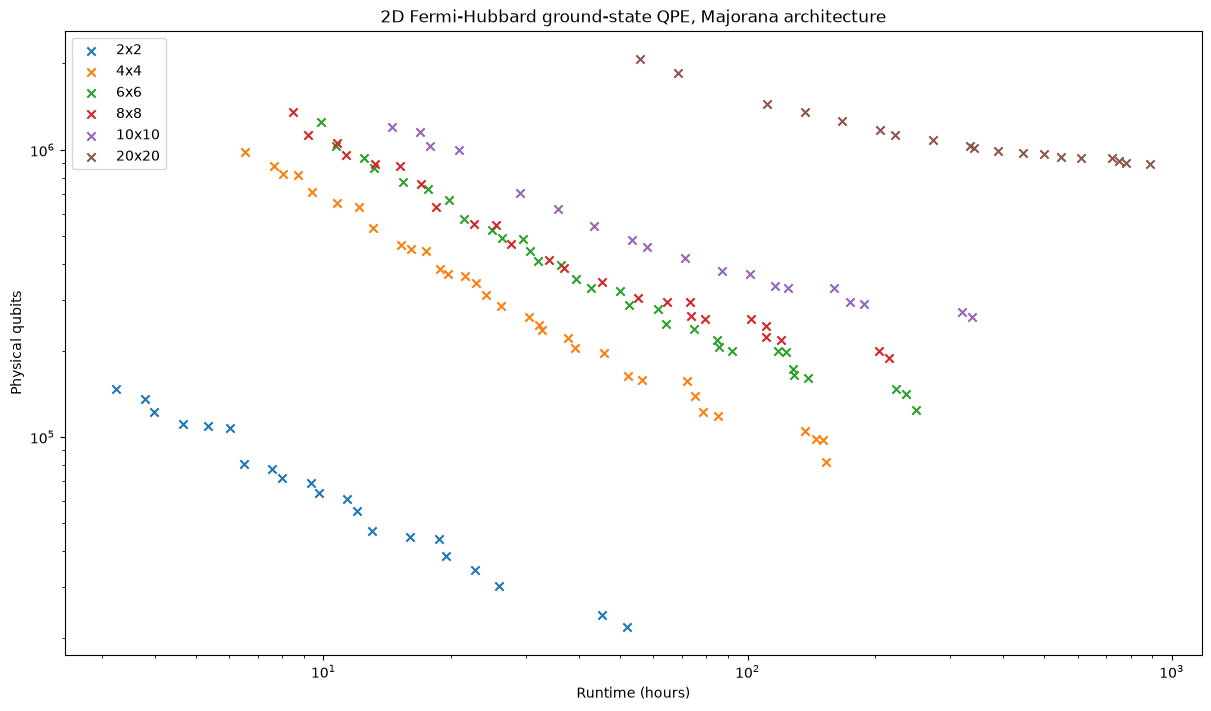

In [ ]:
fig = plot_estimates(tables, runtime_unit="hours", figsize=(12, 7))
ax = fig.axes[0]
ax.set_title("2D Fermi-Hubbard ground-state QPE, Majorana architecture")
fig.set_layout_engine("constrained")
fig

## How far the sweep can go

The benchmark specifies $L$ up to 200; the sweep stops at $L = 20$. Three independent limits, none of which
is the resource estimation itself:

1. **Jordan-Wigner mapper, $L \le 22$ (hard).** `cpp/src/qdk/chemistry/data/majorana_map_engine.cpp` packs
   each Pauli string into a stack-allocated `PackedPauliWord<NW>` of `NW` 64-bit words, with `NW` a *template*
   parameter. `dispatch_by_words` instantiates `majorana_map_impl<1..max_nw>` and selects at runtime, and
   `constexpr std::size_t max_nw = 16` caps the encoding at $16 \times 64 = 1024$ qubits. For this model
   $2N \le 1024$, i.e. $L \le 22$. Raising the cap means recompiling the extension with a larger `max_nw`,
   at the cost of one more instantiation of the mapping kernel per word.
2. **Tracer memory**, which grows like $2^{m} \times r \times n_{\mathrm{terms}}$. This is why the loose
   `trotter_steps_naive` bound is unusable here: ignoring commutation it returns $r = 253$ at *every* size
   (since $\lambda \propto N$ cancels against $t_0 = \pi/\lambda$), roughly $100\times$ the commutator bound,
   and the tracer then attempts a 206 GB allocation at $L = 6$. The tighter bound is what keeps the circuit
   traceable.
3. **Circuit compilation**, about 5 minutes at $L = 20$ and growing with the term count.

Qubitization-based alternatives such as FOQCS or SOSSA would replace the product formula in
`hamiltonian_unitary_builder` and are worth revisiting for the same benchmark:

- [2601.18767v1] Practical block encodings of matrix polynomials that can also be trivially controlled
- [2602.05069v1] Near-frustration-free electronic structure Hamiltonian representations and lower bound certificates

In [ ]:
import matplotlib.pyplot as plt

# For a periodic square lattice, there are 2N edges and two spin sectors.
# The hopping terms contribute 4|T|N to lambda and the on-site terms |U|N.
scaling_sizes = np.arange(2, 201)
scaling_sites = scaling_sizes**2
scaling_one_norm = (4 * abs(HOPPING_T) + abs(COULOMB_U)) * scaling_sites
scaling_precision = TARGET_PRECISION_PER_SITE * scaling_sites
scaling_evolution_time = np.pi / scaling_one_norm
scaling_readout_budget = (1 - TROTTER_ERROR_FRACTION) * scaling_precision
scaling_resolution_bits = np.ceil(np.log2(2 * scaling_one_norm / scaling_readout_budget)).astype(int)
scaling_guard_bits = math.ceil(math.log2(2 + 1 / (2 * QPE_FAILURE_PROBABILITY)))
scaling_num_bits = scaling_resolution_bits + scaling_guard_bits

parameter_scaling = pd.DataFrame(
    {
        "one_norm": scaling_one_norm,
        "evolution_time": scaling_evolution_time,
        "num_bits": scaling_num_bits,
    },
    index=pd.Index(scaling_sizes, name="L"),
)

# Keep the analytic sweep tied to the explicitly constructed example.
assert np.isclose(parameter_scaling.loc[EXAMPLE_NUM_SITES, "one_norm"], parameters.one_norm)
assert np.isclose(parameter_scaling.loc[EXAMPLE_NUM_SITES, "evolution_time"], parameters.evolution_time)
assert parameter_scaling.loc[EXAMPLE_NUM_SITES, "num_bits"] == parameters.num_bits

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
series = [
    ("one_norm", r"Coefficient 1-norm $\lambda$", "log"),
    ("evolution_time", r"Evolution time $t_0$", "log"),
    ("num_bits", "QPE phase bits", "linear"),
]
for ax, (column, title, yscale) in zip(axes, series):
    ax.plot(parameter_scaling.index, parameter_scaling[column], linewidth=2)
    value = parameter_scaling.loc[EXAMPLE_NUM_SITES, column]
    ax.scatter([EXAMPLE_NUM_SITES], [value], color="tab:red", zorder=3)
    ax.annotate(
        f"L={EXAMPLE_NUM_SITES}\n{value:.6g}",
        (EXAMPLE_NUM_SITES, value),
        xytext=(8, 8),
        textcoords="offset points",
    )
    ax.set(title=title, xlabel="Linear lattice size L", yscale=yscale)
    ax.grid(True, which="both", alpha=0.3)

fig.suptitle("2D Fermi-Hubbard QPE parameter scaling")
fig.set_layout_engine("constrained")
fig